# Library Imports

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

In [16]:
df=pd.read_csv('../data/clean_heart.csv')

In [17]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

1. Split Features & Target

In [18]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

2. Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

3. Handled Categorial Data

In [20]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# align columns (VERY IMPORTANT)
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

4. Train Model

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

5. Make Prediction

In [22]:
y_pred = model.predict(X_test)

5. Evaluation Model

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.8586956521739131
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



6. Create prediction function

In [24]:
def predict(model, user_input):
    """
    Make a prediction using the trained model.
    
    Args:
        model: Trained LogisticRegression model
        user_input: Dictionary with user input values
    
    Returns:
        prediction: 0 or 1 (0 = No heart disease, 1 = Yes heart disease)
        probability: Probability of heart disease (value between 0 and 1)
    """
    # Create a DataFrame from user input
    input_df = pd.DataFrame([user_input])
    
    # Apply get_dummies to match training data structure
    input_df = pd.get_dummies(input_df, drop_first=True)
    
    # Align with training features (fill missing columns with 0)
    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)
    
    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    
    return prediction, probability


In [25]:
import ipywidgets as widgets
from IPython.display import display, clear_output

age = widgets.IntText(value=50, description='Age')
sex = widgets.Dropdown(options=['Male', 'Female'], value='Male', description='Sex')
chest_pain_type = widgets.Dropdown(options=[('ATA - Atypical Angina', 'ATA'), ('NAP - Non-Anginal Pain', 'NAP'), ('ASY - Asymptomatic', 'ASY'), ('TA - Typical Angina', 'TA')], value='ATA', description='ChestPainType')
resting_bp = widgets.FloatText(value=120.0, description='RestingBP')
cholesterol = widgets.FloatText(value=200.0, description='Cholesterol')
fasting_bs = widgets.Dropdown(options=[0, 1], value=0, description='FastingBS')
resting_ecg = widgets.Dropdown(options=[('Normal - Normal', 'Normal'), ('ST - ST-T Wave Abnormality', 'ST'), ('LVH - Left Ventricular Hypertrophy', 'LVH')], value='Normal', description='RestingECG')
max_hr = widgets.FloatText(value=150.0, description='MaxHR')
exercise_angina = widgets.Dropdown(options=['Y', 'N'], value='N', description='ExerciseAngina')
oldpeak = widgets.FloatText(value=1.0, description='Oldpeak')
st_slope = widgets.Dropdown(options=['Up', 'Flat', 'Down'], value='Flat', description='ST_Slope')

output = widgets.Output()
button = widgets.Button(description='Predict', button_style='primary')

def on_predict_clicked(_):
    with output:
        clear_output()
        user_input = {
            'Age': age.value,
            'Sex': sex.value,
            'ChestPainType': chest_pain_type.value,
            'RestingBP': resting_bp.value,
            'Cholesterol': cholesterol.value,
            'FastingBS': fasting_bs.value,
            'RestingECG': resting_ecg.value,
            'MaxHR': max_hr.value,
            'ExerciseAngina': exercise_angina.value,
            'Oldpeak': oldpeak.value,
            'ST_Slope': st_slope.value
        }

        prediction, probability = predict(model, user_input)

        print('Prediction result:')
        print('Heart Disease: Yes' if prediction == 1 else 'Heart Disease: No')
        print(f'Probability of heart disease: {probability:.2%}')

button.on_click(on_predict_clicked)
display(widgets.VBox([age, sex, chest_pain_type, resting_bp, cholesterol, fasting_bs, resting_ecg, max_hr, exercise_angina, oldpeak, st_slope, button, output]))

In [26]:
# Ensure training and test variables exist. If not, (re)train the model so plotting cells can run in any order.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

if 'model' not in globals() or 'X_test' not in globals() or 'y_test' not in globals():
    # Load data if missing
    if 'df' not in globals():
        df = pd.read_csv('../data/clean_heart.csv')
    else:
        df = globals().get('df')

    le = LabelEncoder()
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = le.fit_transform(df[col])

    X = df.drop('HeartDisease', axis=1)
    y = df['HeartDisease']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train = pd.get_dummies(X_train)
    X_test = pd.get_dummies(X_test)
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    # If model exists but probabilities/predictions missing, compute them
    if 'y_prob' not in globals():
        y_prob = model.predict_proba(X_test)[:, 1]
    if 'y_pred' not in globals():
        y_pred = model.predict(X_test)

# expose common names to the notebook globals (helps subsequent cells)
globals().update({'model': model, 'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred, 'y_prob': y_prob})

## Performance Metrics and Plots

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve, log_loss)

# Predicted probabilities for ROC/PR and log loss
y_prob = model.predict_proba(X_test)[:, 1]

# Basic scalar metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
ll = log_loss(y_test, y_prob)

print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'Log Loss: {ll:.4f}')

print(classification_report(y_test, y_pred))

Accuracy: 0.8587
Precision: 0.9010
Recall: 0.8505
F1-score: 0.8750
Log Loss: 0.3609
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



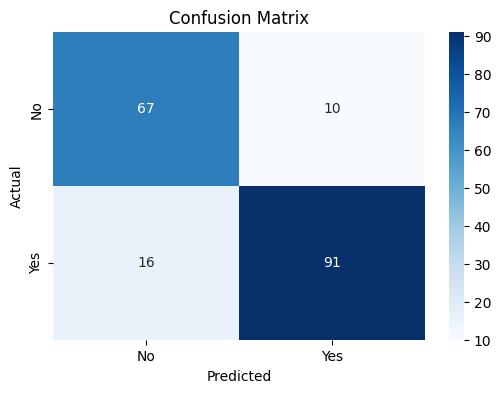

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

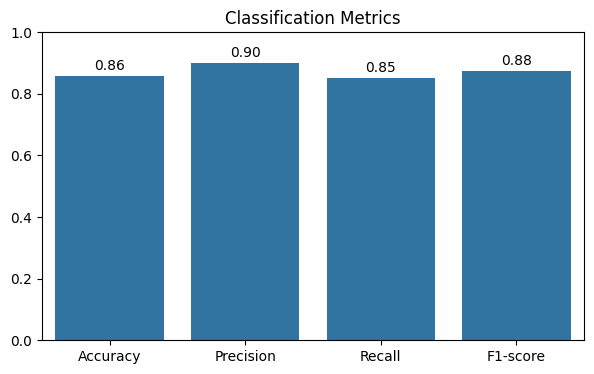

In [29]:
# Bar chart for key metrics
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}
plt.figure(figsize=(7,4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()))
plt.ylim(0,1)
plt.title('Classification Metrics')
for i,v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center')
plt.show()

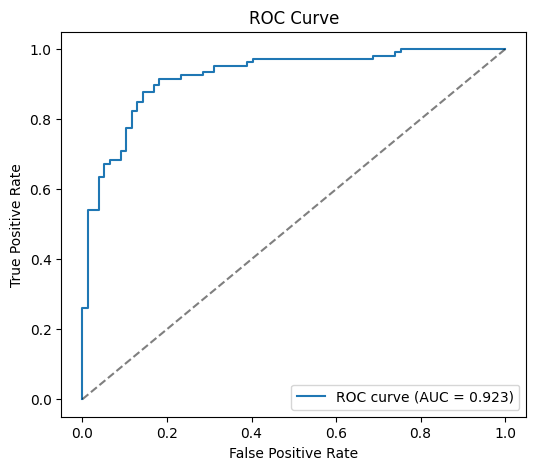

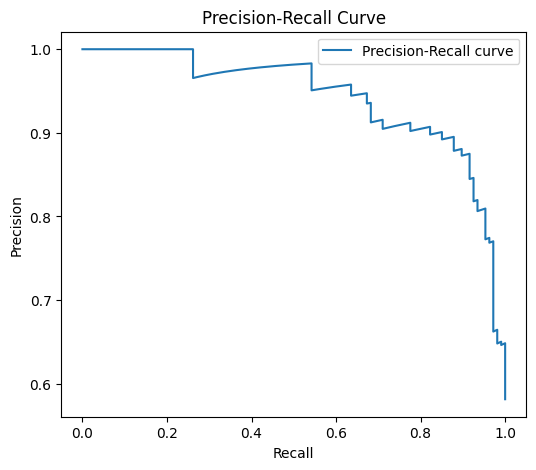

In [30]:
# ROC Curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()